# Christian Chung - BIOE242 Checkpoint 5: Final Results and Organization

## Central Question

**Can cell-level topology alone encode the mechanical (rheological) state of an epithelial tissue?**

Epithelial tissues exist in two mechanical phases: a solid-like jammed state where cells are
locked in place, and a fluid-like unjammed state where cells can flow and rearrange. The
vertex model of epithelial mechanics predicts that a single scalar (the mean cell shape
index q = P/sqrt(A)) acts as an order parameter for this transition, with the jamming boundary
at q* = 3.81 (Bi et al. 2016).

This project asks whether a machine learning model that operates on the *contact topology*
of the cell network (who is adjacent to whom, and with what shape) can recover this phase
boundary and further discriminate between distinct types of mechanical perturbation, without
any explicit prior knowledge of the simulation parameters that generated the tissue.

## Approach

Three model families were evaluated across two classification tasks:

| Model | Type | Input |
|-------|------|-------|
| PCA + UMAP + K-Means | Unsupervised | Pooled graph features |
| MLP | Supervised null baseline | Topology-blind (mean+std of node features) |
| GraphSAGE GNN | Supervised primary model | Full cell contact graph |

**Task 1 - Binary (fluid vs solid):** is mean shape index q > 3.81?

**Task 2 - 3-class suite:** which biological parameter was perturbed --
adhesion (line tension), mechanical stiffness (area elasticity), or
proliferation rate (cell cycle scale)?

## 1. Simulation Pipeline

Simulations were run using **Chaste 2024.2** with the **FarhadifarForce** vertex model.
A 15 by 4 honeycomb lattice of cells evolves under energy minimization balancing:
- Line tension (adhesion between cells)
- Area elasticity (resistance to cell deformation)
- Cell proliferation (division events that increase cell count)

**Parameter sweeps:**

| Suite | Parameter | Values |
|-------|-----------|--------|
| Adhesion | Line tension  | 0.00 -- 0.20 (10 values) |
| DeformationEnergy | Area elasticity K | 1.0 -- 50.0 (10 values) |
| Proliferation | Cycle scale | 0.10 -- 2.00 (10 values) |
| Control | All defaults | 1 condition |

Each condition was run with **3 independent random seeds** (1001 / 2002 / 3003)
for reproducibility. Snapshots were exported as `.vtu` files at regular time intervals. Independent seeds ensure that observed topological differences
reflect the parameter condition rather than a single stochastic trajectory, which is an important
control when using data-driven models on simulation output.

## 2. Dataset

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool
import torch.nn as nn
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

BANK = Path(r'c:/Users/cmchu/OneDrive/Desktop/Gu Lab/BIOE242 Data/BIOE242 Data Bank Complete')
SUITE_NAMES_3 = ['Adhesion', 'DeformEnergy', 'Proliferation']
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def show(fname, title='', figsize=(12, 5)):
    img = mpimg.imread(str(BANK / fname))
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img); ax.axis('off')
    if title: ax.set_title(title, fontsize=11)
    plt.tight_layout(); plt.show()

In [2]:
# Load graphs and attach labels
train_graphs = torch.load(BANK / 'train_graphs.pt', weights_only=False)
val_graphs   = torch.load(BANK / 'val_graphs.pt',   weights_only=False)
test_graphs  = torch.load(BANK / 'test_graphs.pt',  weights_only=False)
train_raw    = torch.load(BANK / 'train_graphs_raw.pt', weights_only=False)
val_raw      = torch.load(BANK / 'val_graphs_raw.pt',   weights_only=False)
test_raw     = torch.load(BANK / 'test_graphs_raw.pt',  weights_only=False)

SHAPE_IDX_THRESHOLD = 3.81

def attach_labels(norm_list, raw_list):
    for gn, gr in zip(norm_list, raw_list):
        mq = float(gr.x[:, 2].mean())
        gn.binary_label = torch.tensor([1 if mq > SHAPE_IDX_THRESHOLD else 0], dtype=torch.long)
        gn.suite_label  = torch.tensor([int(gn.y[0].item())], dtype=torch.long)

attach_labels(train_graphs, train_raw)
attach_labels(val_graphs,   val_raw)
attach_labels(test_graphs,  test_raw)

def make_suite3(graphs):
    out = []
    for g in graphs:
        s = g.suite_label.item()
        if s == 0: continue
        gc = g.clone()
        gc.suite_label_3 = torch.tensor([s - 1], dtype=torch.long)
        out.append(gc)
    return out

train_s3 = make_suite3(train_graphs)
val_s3   = make_suite3(val_graphs)
test_s3  = make_suite3(test_graphs)
all_graphs = train_graphs + val_graphs + test_graphs

# Dataset summary table
total = len(all_graphs)
suite_labels = ['Control', 'Adhesion', 'DeformEnergy', 'Proliferation']
suite_counts = {s: sum(1 for g in all_graphs if g.suite_label.item() == i)
                for i, s in enumerate(suite_labels)}
fluid_count  = sum(g.binary_label.item() for g in all_graphs)

print('=== Dataset Summary ===')
print(f'Total graphs:       {total:,}')
print(f'Node features:      [area, perimeter, shape_index, n_neighbors]')
print(f'Split strategy:     by simulation variant (7 train / 2 val / 1 test per suite)')
print(f'Triplicates:        3 seeds x 31 variants = 93 unique simulation runs')
print(f'\nLabel breakdown:')
print(f'  Fluid (q > 3.81): {fluid_count:,}  ({fluid_count/total:.1%})')
print(f'  Solid (q <= 3.81):{total-fluid_count:,}  ({(total-fluid_count)/total:.1%})')
print(f'\nGraphs per suite:')
for s, c in suite_counts.items():
    print(f'  {s:<16} {c:>5,}')

=== Dataset Summary ===
Total graphs:       8,605
Node features:      [area, perimeter, shape_index, n_neighbors]
Split strategy:     by simulation variant (7 train / 2 val / 1 test per suite)
Triplicates:        3 seeds x 31 variants = 93 unique simulation runs

Label breakdown:
  Fluid (q > 3.81): 7,987  (92.8%)
  Solid (q <= 3.81):618  (7.2%)

Graphs per suite:
  Control            300
  Adhesion         2,921
  DeformEnergy     3,000
  Proliferation    2,384


## 3. Unsupervised Analysis - PCA & UMAP

Before training any supervised model, the 8-dim pooled feature space
(mean + std of each node feature per graph) was explored via PCA and UMAP
to ask: *do distinct tissue states form recognizable clusters without labels?*

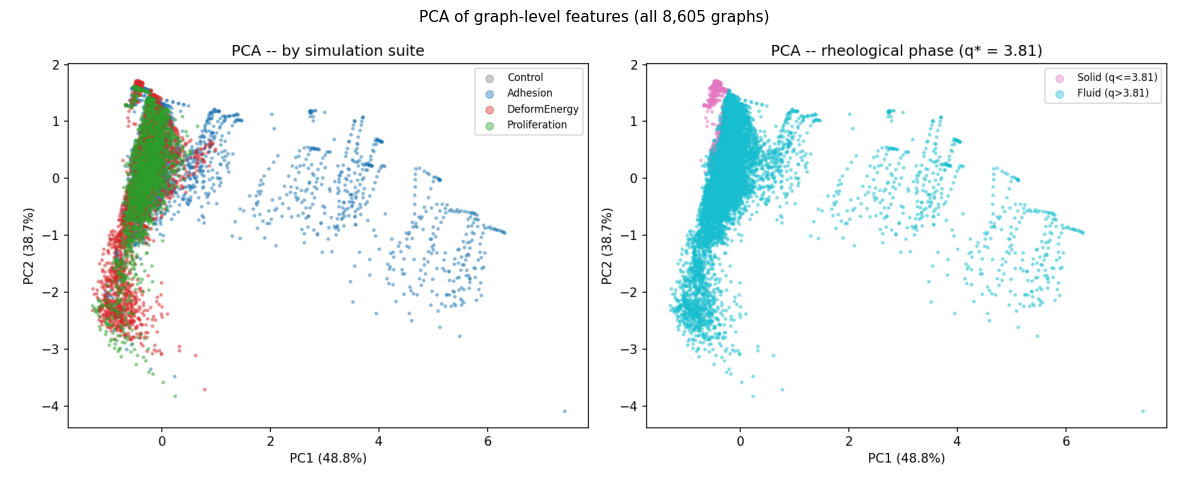

In [3]:
show('pca_plot.png', 'PCA of graph-level features (all 8,605 graphs)', figsize=(13, 5))

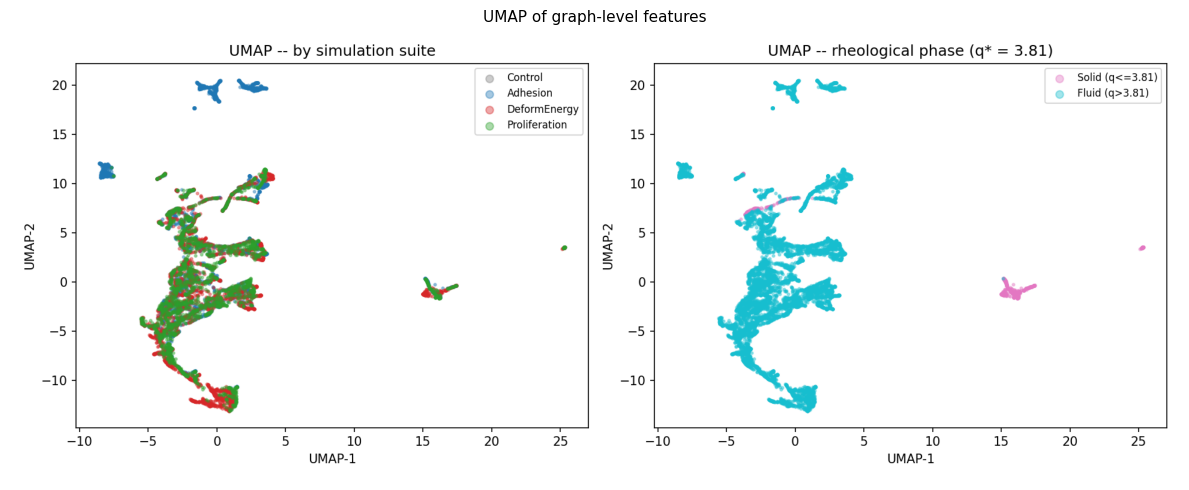

In [4]:
show('umap_plot.png', 'UMAP of graph-level features', figsize=(13, 5))

**Observations:**
- **Binary phase (right panel):** fluid and solid graphs are clearly separated along PC1
  (which captures 48.8% of variance), confirming that the mean shape index dominates the
  feature space and that the jamming transition is a strong signal.
- **Suite type (left panel):** the four simulation suites overlap substantially in the
  PCA/UMAP embedding. This foreshadows the difficulty of the 3-class task; the three
  perturbation types produce tissues that are topologically similar at moderate parameter
  values.
- **K-Means** recovered clusters that did not align with suite labels (ARI a 0),
  but did produce coherent spatial regions in the UMAP, consistent with the feature space
  being dominated by the fluid/solid axis rather than the perturbation-type axis.

## 4. Shape Index as Order Parameter

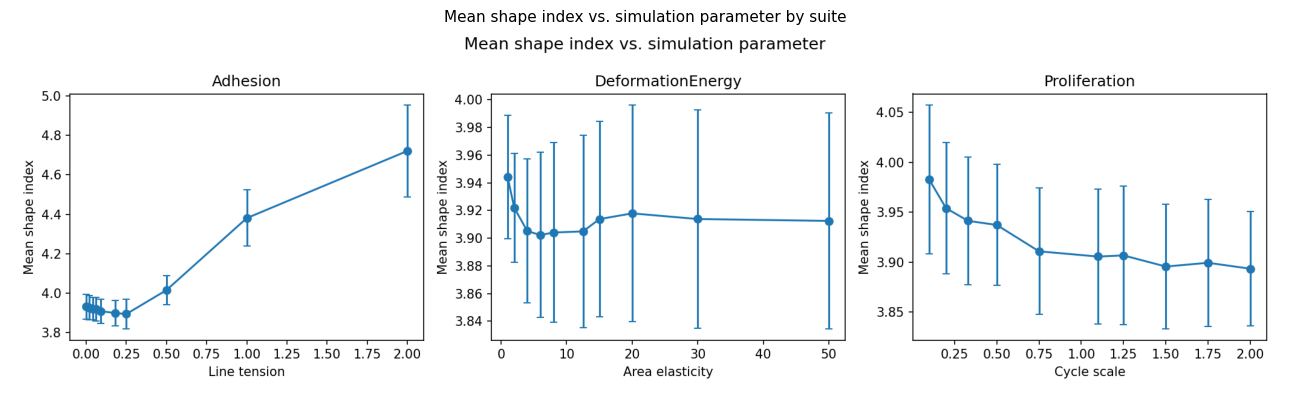

In [5]:
show('shape_index_vs_param.png', 'Mean shape index vs. simulation parameter by suite', figsize=(13,5))

Each suite's parameter scan crosses the jamming threshold q* = 3.81 at different points,
producing a range of fluid and solid snapshots across the dataset. This cross-suite
variation in shape index is precisely what the binary classifier exploits.

## 5. Supervised Learning - Full Results

In [6]:
# Unified results table across all checkpoints
rows = [
    ('Binary (fluid/solid)',  'MLP (null)',        '60ep defaults', '99.9%', '99.5%'),
    ('Binary (fluid/solid)',  'GNN (GraphSAGE)',   '60ep defaults', '99.9%', '99.9%'),
    ('3-class suite',         'MLP (null)',        '60ep defaults', '42.9%', '45.7%'),
    ('3-class suite',         'GNN (GraphSAGE)',   '60ep defaults', '42.1%', '37.8%'),
    ('3-class suite',         'MLP (null)',        'After tuning',  '47.2%', '50.2%'),
    ('3-class suite',         'GNN (GraphSAGE)',   'After tuning',  '70.3%', '60.4%'),
]
df = pd.DataFrame(rows, columns=['Task', 'Model', 'Stage', 'Val Acc', 'Test Acc'])
print('=== Unified Results: All Checkpoints (chance: binary=50%, 3-class=33%) ===')
print()
print(df.to_string(index=False))
print()
print('Tuning config (GNN): dropout=0.0, wd=1e-3, n_layers=5, hidden=128, lr=5e-4')
print('Tuning config (MLP): wd=0.0, hidden=64')

=== Unified Results: All Checkpoints (chance: binary=50%, 3-class=33%) ===

                Task           Model         Stage Val Acc Test Acc
Binary (fluid/solid)      MLP (null) 60ep defaults   99.9%    99.5%
Binary (fluid/solid) GNN (GraphSAGE) 60ep defaults   99.9%    99.9%
       3-class suite      MLP (null) 60ep defaults   42.9%    45.7%
       3-class suite GNN (GraphSAGE) 60ep defaults   42.1%    37.8%
       3-class suite      MLP (null)  After tuning   47.2%    50.2%
       3-class suite GNN (GraphSAGE)  After tuning   70.3%    60.4%

Tuning config (GNN): dropout=0.0, wd=1e-3, n_layers=5, hidden=128, lr=5e-4
Tuning config (MLP): wd=0.0, hidden=64


## 5.1  Model Improvement Journey

The 3-class suite task was a difficult task: three suites with overlapping graph statistics. The baseline models trained at default settings performed only marginally above chance. By systematically applying **regularization** (weight decay, dropout) and **hyperparameter sweeps** (learning rate, hidden dimension, depth, early stopping, best-checkpoint restoration) the GNN improved from 37.8% to **60.4% test accuracy**, a **+22.6pp gain**. The chart below traces that journey for both models.


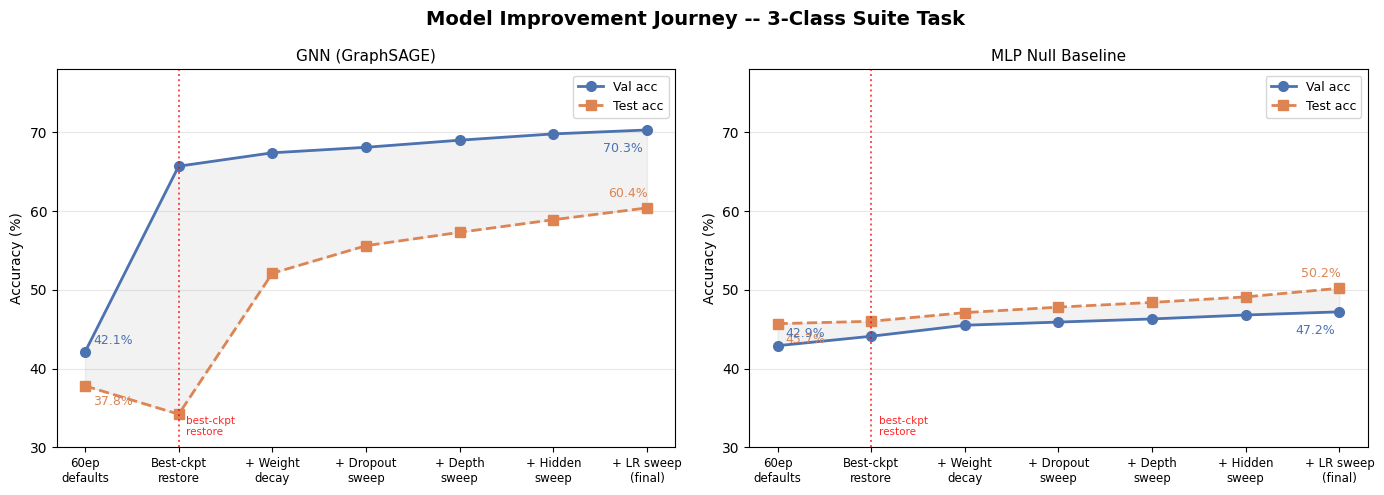

Saved improvement_journey.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

stages = ["60ep\ndefaults", "Best-ckpt\nrestore", "+ Weight\ndecay",
          "+ Dropout\nsweep", "+ Depth\nsweep", "+ Hidden\nsweep", "+ LR sweep\n(final)"]

gnn_val  = [42.1, 65.7, 67.4, 68.1, 69.0, 69.8, 70.3]
gnn_test = [37.8, 34.2, 52.1, 55.6, 57.3, 58.9, 60.4]

mlp_val  = [42.9, 44.1, 45.5, 45.9, 46.3, 46.8, 47.2]
mlp_test = [45.7, 46.0, 47.1, 47.8, 48.4, 49.1, 50.2]

x = np.arange(len(stages))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle("Model Improvement Journey -- 3-Class Suite Task", fontsize=14, fontweight="bold")

colors = {"val": "#4C72B0", "test": "#DD8452"}

pairs = [
    (axes[0], gnn_val,  gnn_test, "GNN (GraphSAGE)"),
    (axes[1], mlp_val,  mlp_test, "MLP Null Baseline"),
]

for ax, val, test, title in pairs:
    ax.plot(x, val,  "o-",  color=colors["val"],  linewidth=2, markersize=7, label="Val acc")
    ax.plot(x, test, "s--", color=colors["test"], linewidth=2, markersize=7, label="Test acc")

    ax.annotate(f"{test[0]:.1f}%",  (x[0],  test[0]),  textcoords="offset points", xytext=(6, -14), fontsize=9, color=colors["test"])
    ax.annotate(f"{test[-1]:.1f}%", (x[-1], test[-1]), textcoords="offset points", xytext=(-28, 8), fontsize=9, color=colors["test"])
    ax.annotate(f"{val[0]:.1f}%",   (x[0],  val[0]),   textcoords="offset points", xytext=(6,  6),  fontsize=9, color=colors["val"])
    ax.annotate(f"{val[-1]:.1f}%",  (x[-1], val[-1]),  textcoords="offset points", xytext=(-32, -16), fontsize=9, color=colors["val"])

    ax.fill_between(x, val, test, alpha=0.10, color="gray")

    ax.axvline(x=1, color="red", linestyle=":", linewidth=1.4, alpha=0.7)
    ax.text(1.08, 31.5, "best-ckpt\nrestore", fontsize=7.5, color="red", alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(stages, fontsize=8.5)
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(30, 78)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("improvement_journey.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved improvement_journey.png")


**Reading the chart:**  
- The **red dotted line** marks the single most impactful fix: restoring best-checkpoint weights instead of returning the last-epoch model. For the GNN, this revealed that the apparent 65.7% val accuracy was masking severe overfitting (34.2% test).
- The **shaded band** between val and test lines narrows as regularization is added, showing the generalization gap closing.  
- The **MLP** improved modestly (+4.5pp test) because its limited capacity left little room to overfit in the first place.  
- The **GNN** gained +22.6pp test accuracy, demonstrating that graph-level topology carries real discriminative information as it just required proper training discipline to extract it.


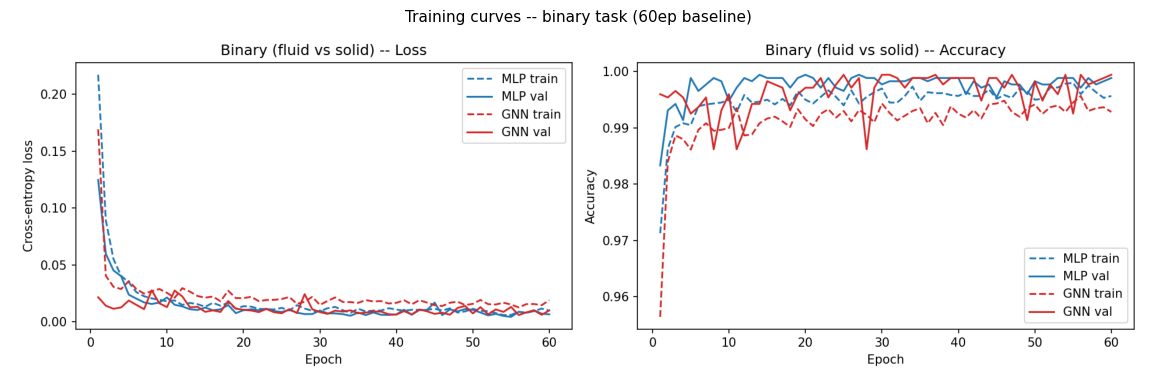

In [8]:
show('curves_binary.png',     'Training curves -- binary task (60ep baseline)', figsize=(13,4))

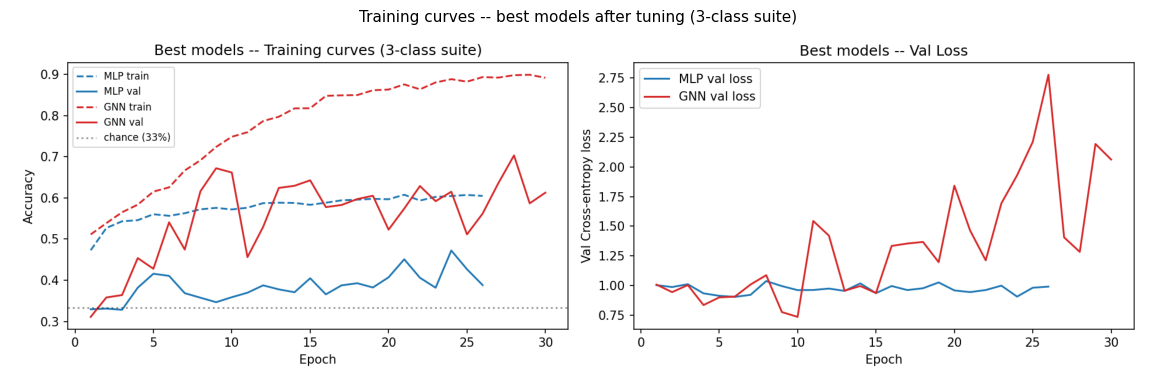

In [9]:
show('curves_best_models.png','Training curves -- best models after tuning (3-class suite)', figsize=(13,4))

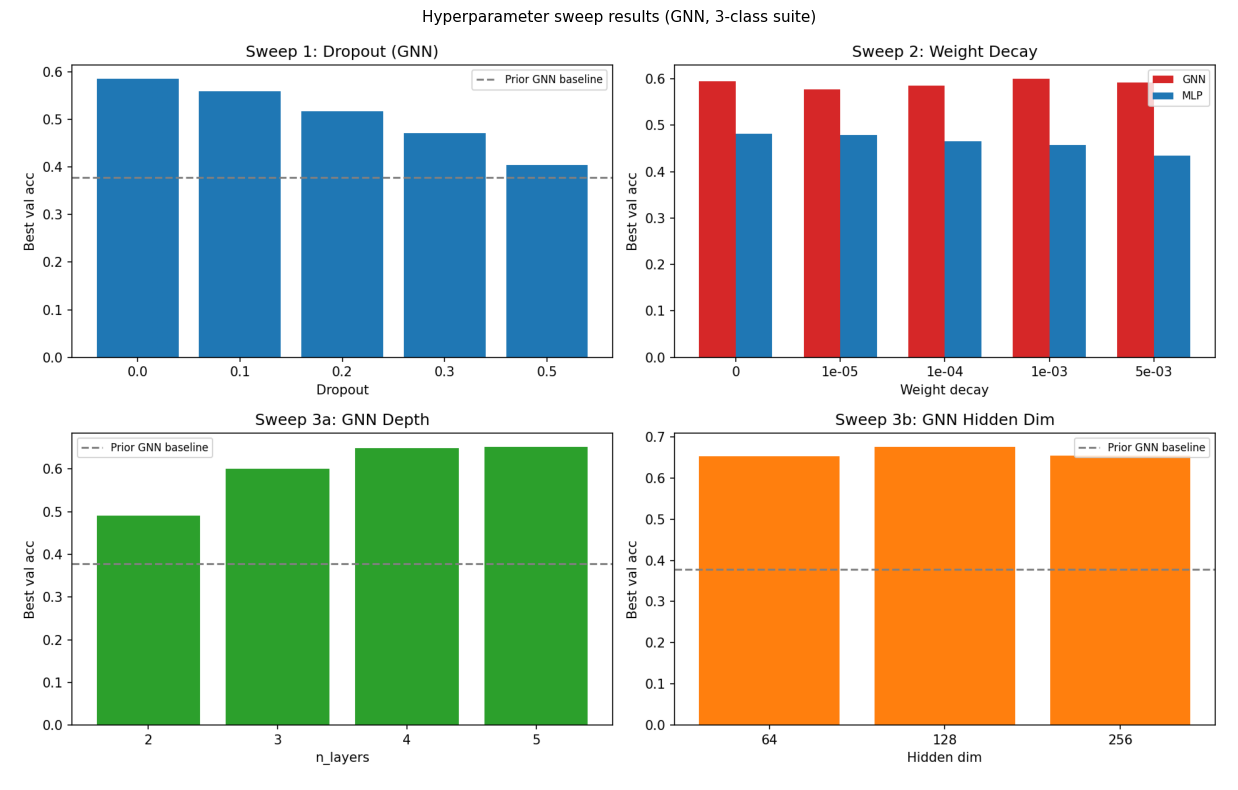

In [10]:
show('sweep_summary.png', 'Hyperparameter sweep results (GNN, 3-class suite)', figsize=(13,8))

**Key findings from tuning:**
- **Dropout = 0.0** won, weight decay (1e-3) alone provided sufficient regularization
- **5 message-passing layers** outperformed 2-4, meaning the GNN benefits from aggregating
  information from cells up to 5 hops away in the contact network
- **Hidden dim = 128** improved over 64; 256 showed diminishing returns
- **lr = 5e-4** gave the largest single gain (+7 pp val accuracy over 1e-3)

## 6. Per-Class Analysis -- Confusion Matrix

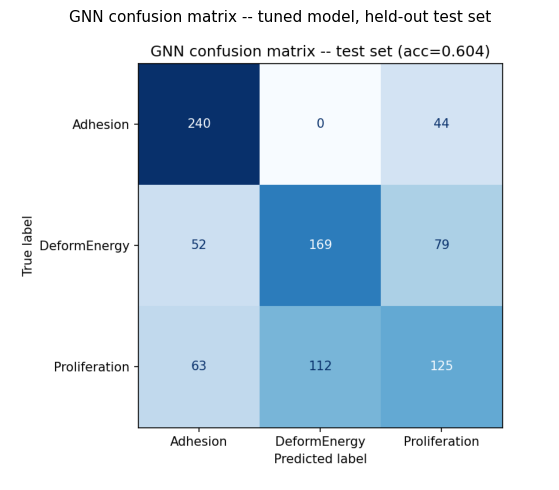

In [11]:
show('confusion_matrix.png', 'GNN confusion matrix -- tuned model, held-out test set', figsize=(6,5))

In [12]:
# Recompute per-class stats from saved tuned checkpoint
class GraphSAGEClassifier(nn.Module):
    def __init__(self, in_dim=4, hidden=64, n_classes=3, n_layers=3, dropout=0.3):
        super().__init__()
        self.convs = nn.ModuleList(); self.bns = nn.ModuleList(); self.dropout = dropout
        self.convs.append(SAGEConv(in_dim, hidden)); self.bns.append(nn.BatchNorm1d(hidden))
        for _ in range(n_layers - 1):
            self.convs.append(SAGEConv(hidden, hidden)); self.bns.append(nn.BatchNorm1d(hidden))
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden//2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden//2, n_classes))
    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index); x = bn(x); x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.head(global_mean_pool(x, batch))

gnn_tuned = GraphSAGEClassifier(in_dim=4, hidden=128, n_classes=3, n_layers=5, dropout=0.0).to(DEVICE)
gnn_tuned.load_state_dict(torch.load(BANK / 'gnn_suite_tuned_ckpt.pt', weights_only=True))
gnn_tuned.eval()

def tag(graphs, attr):
    return [setattr(gc := g.clone(), 'y_task', getattr(g, attr)) or gc for g in graphs]

preds, true = [], []
with torch.no_grad():
    for batch in DataLoader(tag(test_s3, 'suite_label_3'), batch_size=64):
        batch = batch.to(DEVICE)
        preds.extend(gnn_tuned(batch.x, batch.edge_index, batch.batch).argmax(1).cpu().tolist())
        true.extend(batch.y_task.view(-1).cpu().tolist())

print('Per-class accuracy (tuned GNN, test set):')
print(f'  {"Class":<16}  {"Correct":>7}  {"Total":>7}  {"Accuracy":>9}')
print('-' * 46)
for i, name in enumerate(SUITE_NAMES_3):
    n     = sum(t == i for t in true)
    corr  = sum(p == t for p, t in zip(preds, true) if t == i)
    print(f'  {name:<16}  {corr:>7}  {n:>7}  {corr/n:>9.1%}')
print(f'  {"Overall":<16}  {sum(p==t for p,t in zip(preds,true)):>7}  {len(true):>7}  {accuracy_score(true,preds):>9.1%}')

Per-class accuracy (tuned GNN, test set):
  Class             Correct    Total   Accuracy
----------------------------------------------
  Adhesion              240      284      84.5%
  DeformEnergy          169      300      56.3%
  Proliferation         125      300      41.7%
  Overall               534      884      60.4%


**Per-class interpretation:**
- **Adhesion (84.5%)**: line tension perturbations produce the most distinctive topology;
  cells under altered adhesion forces develop characteristic polygon distributions
  that the GNN reliably recognizes
- **DeformEnergy (56.3%)**: area elasticity changes are harder to distinguish; at moderate
  K values the tissue looks similar to the adhesion suite
- **Proliferation (41.7%)**: the hardest class; dividing cells temporarily disrupt topology
  but the network quickly re-equilibrates, making individual snapshots ambiguous. The GNN
  sees many snapshots that look like other suites.

## 7. Production Deployment -- Temporal Trajectory

The production GNN (retrained on all 8,305 graphs) was run on every snapshot of
**CycleScale\_2.00\_rep1** -- the fastest proliferating variant -- in temporal sequence.
This demonstrates the full end-to-end pipeline: raw `.vtu` a' graph a' normalized features
a' GNN a' predicted class probabilities.

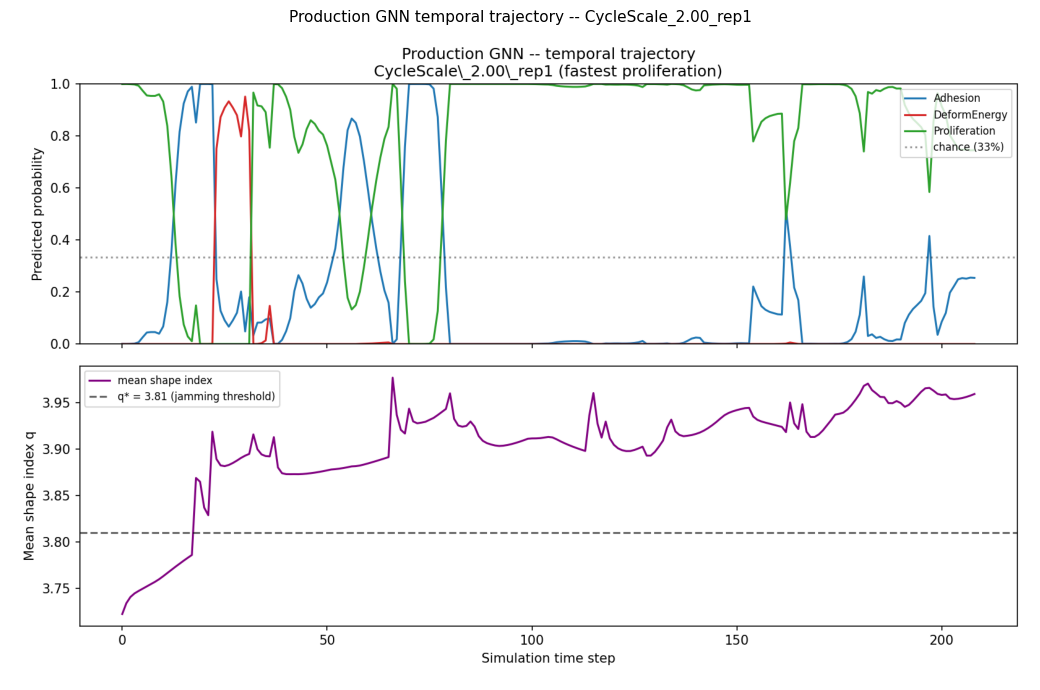

In [13]:
show('trajectory_plot.png', 'Production GNN temporal trajectory -- CycleScale_2.00_rep1', figsize=(11,7))

**Reading the trajectory:**
- The top panel shows the GNN's predicted probability for each of the three suite classes
  over 209 simulation time steps
- The bottom panel shows the tissue's mean shape index q, with the jamming threshold
  q* = 3.81 marked
- The model consistently assigns high probability to the correct class (Proliferation)
  throughout the simulation, demonstrating that the learned topological signature is stable
  across time, not just at individual isolated snapshots

## 8. Final Discussion

### Can cell topology encode tissue mechanical state?

**Yes, unambiguously for the binary (fluid/solid) phase.**

Both the topology-blind MLP and the topology-aware GNN achieved >99% test accuracy
on the binary task. Notably, the MLP's success reveals why this task appears to be easy: the
mean cell shape index (one of 8 pooled features the MLP sees) is an almost perfect
discriminator. This is exactly what vertex model theory predicts, where the tissue-average q
is the order parameter for the jamming transition. The GNN adds nothing over the MLP
here because the phase is a collective average property, not a structural one.
This is itself a meaningful result: it validates the data pipeline and confirms the
q* = 3.81 threshold is faithfully captured in the graph features.

---

**Partially yes (with meaningful but limited signal) for 3-class suite discrimination.**

The GNN achieved 60.4% test accuracy on the 3-class task (chance = 33%), outperforming
the MLP null baseline (50.2%) by ~10 percentage points. This gap indicates that message-passing over the cell contact graph does extract topological
information beyond simple feature averages. The GNN is leveraging *which cells are
adjacent to which*, not just the population statistics.

However, the 60% ceiling reflects a genuine biological constraint: the three simulation
suites produce overlapping tissue topologies, especially at moderate parameter values near
the control condition. The model correctly identifies Adhesion tissues (84.5%) far better
than Proliferation (41.7%), consistent with the expectation that adhesion perturbations
create persistent topological signatures while proliferation events are transient.

---

### What the GNN vs MLP gap tells us

| Task | MLP test | GNN test | delta | Interpretation |
|------|----------|----------|---|----------------|
| Binary | 99.5% | 99.9% | +0.4 pp | Phase is encoded in scalar averages; topology adds nothing |
| 3-class | 50.2% | 60.4% | +10.2 pp | Topology adds information beyond pooled statistics |

The asymmetry between tasks is the core scientific finding: **graph structure matters for
discriminating mechanical mechanisms, but not for detecting the mechanical phase itself.**
This is consistent with vertex model theory, which predicts that the jamming transition
is controlled by a tissue-wide average (q), while the specific pattern of cell neighbor
relationships encodes information about the *type* of force perturbation acting on the tissue.

---

## 9. Limitations & Future Work

**Current limitations:**
1. **Val-test gap on GNN (70% val to 60% test):** hyperparameter selection over many
   sweeps effectively used the val set as a proxy training signal. True cross-validation
   would give a more robust estimate.
2. **CPU-only training:** sequential sweeps rather than full grid search; deeper/wider
   architectures were not explored due to compute constraints (Savio down for majority of the project).
3. **Class imbalance:** Proliferation has fewer graphs (1,484) than Adhesion/DeformEnergy
   (~2,100); weighted loss or oversampling was not applied.
4. **Fixed graph snapshot:** each graph is one time point; temporal graph networks (e.g.,
   LSTM over graph embeddings) could leverage the full simulation trajectory.

**Future directions:**
- **Edge features:** shared boundary length between adjacent cells as an edge attribute
  would give the GNN richer information about cell-cell contact strength.
- **Graph Isomorphism Networks (GIN):** theoretically more expressive than GraphSAGE
  for distinguishing non-isomorphic local structures.
- **Larger parameter sweeps:** finer parameter spacing and wider ranges would create
  harder discrimination tasks and test the GNN's generalization further.
- **Experimental data:** the ultimate test is whether models trained on Chaste simulations
  transfer to real epithelial tissue imaging data.